# 03 - Hidden Markov Model: Market Regime Detection

## Project: Crypto Market Regime Detection using Hidden Markov Models

This notebook applies a Gaussian HMM to the standardized features to discover hidden market regimes (bull, bear, lateral) in Bitcoin's price history.

**Key concepts:**
- Transition matrix: how the market moves between regimes
- Emission distributions: how each regime "looks" in terms of features
- Viterbi decoding: finding the most probable sequence of regimes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from hmmlearn.hmm import GaussianHMM

plt.style.use('seaborn-v0_8-darkgrid')
btc_scaled = pd.read_csv('../data/raw/btc_features_scaled.csv', index_col='Date', parse_dates=True)
# scaler = joblib.load('../data/raw/feature_scaler.pkl')
btc_raw = pd.read_csv('../data/raw/btc_usd_raw.csv', index_col='Date', parse_dates=True)

print("Features shape:", btc_scaled.shape)
btc_scaled.head()

Features shape: (2957, 6)


,log_returns,volatility_7d,volatility_21d,rsi,macd_diff,volume_norm
Date,,,,,,
2018-02-03,1.113386,1.895680,2.445072,-1.428217,-0.379480,-1.013379
2018-02-04,-3.075479,1.803715,2.603447,-1.706348,-0.468625,-1.030640
2018-02-05,-5.181169,2.702304,3.094989,-2.033703,-0.676550,-0.375841
2018-02-06,3.203808,3.975173,2.925583,-1.516760,-0.629225,1.043060
2018-02-07,-0.532652,3.870700,2.924037,-1.553866,-0.562311,-0.225839


### 3.1 Selecting optimal number of states

We test HMMs with 2 to 5 hidden states and compare using AIC and BIC. Lower values indicate a better balance between model fit and complexity.

In [3]:
x = btc_scaled.values
n_range = range(2,6)
models = {}
result = []

for n in n_range:
    best = -np.inf
    best_model= None

    for attempt in range(10):
        model = GaussianHMM(n_components=n,covariance_type='full',n_iter=200,random_state=attempt)
        try:
            model.fit(x)
            score = model.score(x)
            if score> best:
                best = score
                best_model= model
        except:
            continue

    models[n]= best_model
    aic = -2 * best + 2 * (n * n + n * 6 * 2)
    bic = -2 * best + np.log(len(x)) * (n * n + n * 6 * 2)
    result.append({'n_states': n, 'log_likelihood': best, 'AIC': aic, 'BIC': bic})
    print(f"States={n}: Log-Likelihood={best:.2f}, AIC={aic:.2f}, BIC={bic:.2f}")

results_df = pd.DataFrame(result)

States=2: Log-Likelihood=-20488.75, AIC=41033.50, BIC=41201.27
States=3: Log-Likelihood=-18979.54, AIC=38049.07, BIC=38318.71
States=4: Log-Likelihood=-18006.44, AIC=36140.88, BIC=36524.36
States=5: Log-Likelihood=-17323.62, AIC=34817.25, BIC=35326.56


In [4]:

for metric in ['AIC', 'BIC']:
    print(f"\n--- {metric} ---")
    values = results_df[metric].values
    for i in range(1, len(values)):
        improvement = values[i-1] - values[i]
        pct = (improvement / abs(values[i-1])) * 100
        print(f"  {i+1}→{i+2} states: improvement = {improvement:.2f} ({pct:.1f}%)")


--- AIC ---
  2→3 states: improvement = 2984.43 (7.3%)
  3→4 states: improvement = 1908.19 (5.0%)
  4→5 states: improvement = 1323.63 (3.7%)

--- BIC ---
  2→3 states: improvement = 2882.56 (7.0%)
  3→4 states: improvement = 1794.34 (4.7%)
  4→5 states: improvement = 1197.80 (3.3%)


### 3.3 Model

For a 3 statements analisys, decide wich one its the most apropiated.

In [8]:
best_model = models[3]
hidden_states = best_model.predict(x)
btc_scaled['regime'] = hidden_states
btc_raw_aligned = btc_raw.loc[btc_scaled.index].copy()
btc_raw_aligned['regime'] = hidden_states

print("Shape btc_scaled:", btc_scaled.shape)
print("Shape btc_raw_aligned:", btc_raw_aligned.shape)
print("\nDistribución de estados:")
print(pd.Series(hidden_states).value_counts().sort_index())



Shape btc_scaled: (2957, 7)
Shape btc_raw_aligned: (2957, 6)

Distribución de estados:
0     829
1    1093
2    1035
Name: count, dtype: int64


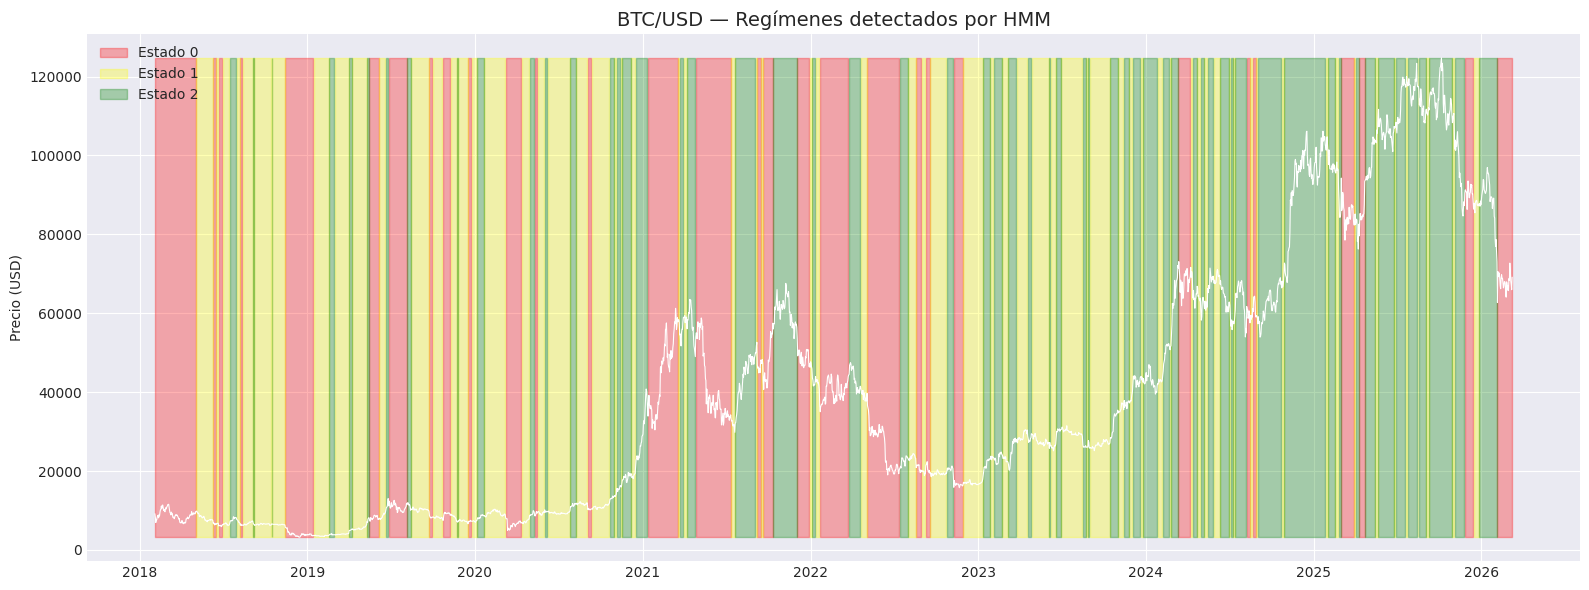

In [11]:
colors = {0: 'red', 1: 'yellow', 2: 'green'} 
labels = {0: 'Estado 0', 1: 'Estado 1', 2: 'Estado 2'}

fig, ax = plt.subplots(figsize=(16, 6))

for state in [0, 1, 2]:
    mask = btc_raw_aligned['regime'] == state
    ax.fill_between(
        btc_raw_aligned.index,
        btc_raw_aligned['Close'].min(),
        btc_raw_aligned['Close'].max(),
        where=mask,
        alpha=0.3,
        color=colors[state],
        label=labels[state]
    )

# Precio encima
ax.plot(btc_raw_aligned.index, btc_raw_aligned['Close'], color='white', linewidth=0.8)
ax.set_title('BTC/USD — Regímenes detectados por HMM', fontsize=14)
ax.set_ylabel('Precio (USD)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
print("Matriz de transición:")
print(pd.DataFrame(
    best_model.transmat_,
    index=['Estado 0', 'Estado 1', 'Estado 2'],
    columns=['→ 0', '→ 1', '→ 2']
).round(3))


Matriz de transición:
            → 0    → 1    → 2
Estado 0  0.962  0.031  0.007
Estado 1  0.017  0.927  0.056
Estado 2  0.013  0.051  0.935


### Regimen Analisys
We need to know the caracteristic of each state to tag them. We gonna reach that calculate the mean for each feature per regimen.

In [14]:
regime_stats = btc_scaled.groupby('regime')[
    ['log_returns', 'volatility_7d', 'volatility_21d', 'rsi', 'macd_diff', 'volume_norm']
].mean().round(3)

print(regime_stats)

        log_returns  volatility_7d  volatility_21d    rsi  macd_diff  \
regime                                                                 
0            -0.092          0.935           1.095 -0.471      0.023   
1            -0.020         -0.577          -0.460 -0.074     -0.022   
2             0.095         -0.139          -0.391  0.456      0.004   

        volume_norm  
regime               
0            -0.107  
1            -0.259  
2             0.360  


In [15]:
regime_labels = {0: 'Bear', 1: 'Sideways', 2: 'Bull'}

btc_scaled['regime_label'] = btc_scaled['regime'].map(regime_labels)
btc_raw_aligned['regime_label'] = btc_raw_aligned['regime'].map(regime_labels)

print(btc_raw_aligned['regime_label'].value_counts())


regime_label
Sideways    1093
Bull        1035
Bear         829
Name: count, dtype: int64


In [18]:
joblib.dump(best_model, '../data/raw/hmm_model.pkl')

btc_raw_aligned.to_csv('../data/raw/btc_regimes.csv')


print(btc_raw_aligned.columns.tolist())
print("\nShape:", btc_raw_aligned.shape)


['Close', 'High', 'Low', 'Open', 'Volume', 'regime', 'regime_label']

Shape: (2957, 7)
